In [ ]:
'!pip install numpy pandas matplotlib seaborn scikit-learn torch torchvision torchaudio tqdm


In [ ]:
import numpy as np
import pandas as pd

# Generate 1000 normal readings
normal_data = np.random.normal(loc=50, scale=5, size=(1000, 1))

# Inject 20 anomalies
anomalies = np.random.normal(loc=100, scale=5, size=(20, 1))

# Combine normal and anomalous data
data = np.vstack([normal_data, anomalies])

# Create DataFrame
df = pd.DataFrame(data, columns=['sensor_value'])
df['label'] = [0]*1000 + [1]*20  # 0=normal, 1=anomaly

# Shuffle the dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save to CSV
df.to_csv("Synthetic_IoT_Anomaly_Dataset.csv", index=False)

# Show first few rows
df.head(10)


,sensor_value,label
0,50.080444,0
1,44.002951,0
2,48.308350,0
3,52.897274,0
4,48.905947,0
5,51.520598,0
6,50.360341,0
7,47.463815,0
8,56.622074,0
9,40.892939,0


First 10 rows:
    sensor_value  label
0     50.080444      0
1     44.002951      0
2     48.308350      0
3     52.897274      0
4     48.905947      0
5     51.520598      0
6     50.360341      0
7     47.463815      0
8     56.622074      0
9     40.892939      0

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sensor_value  1020 non-null   float64
 1   label         1020 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 16.1 KB
None

Missing values:
 sensor_value    0
label           0
dtype: int64


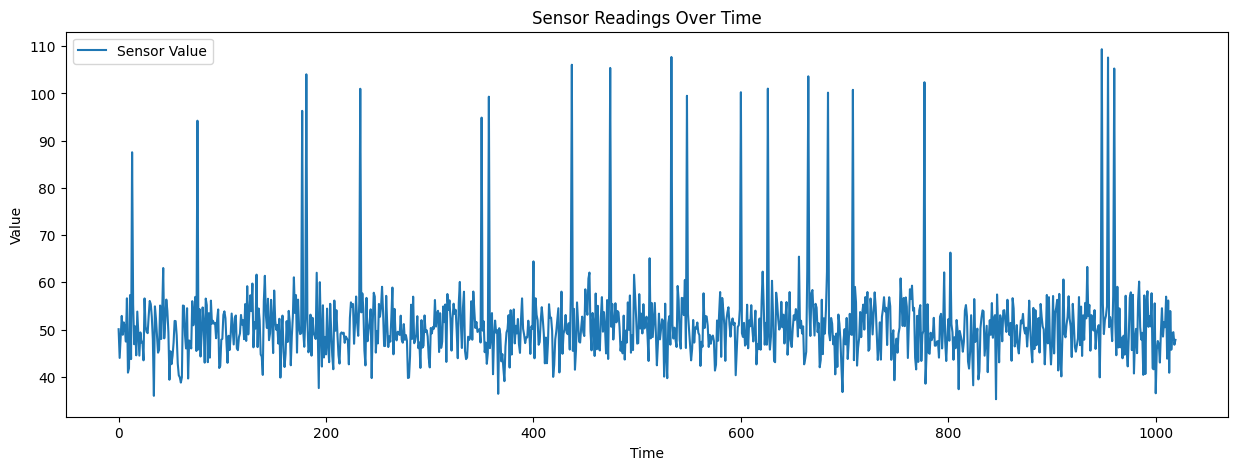

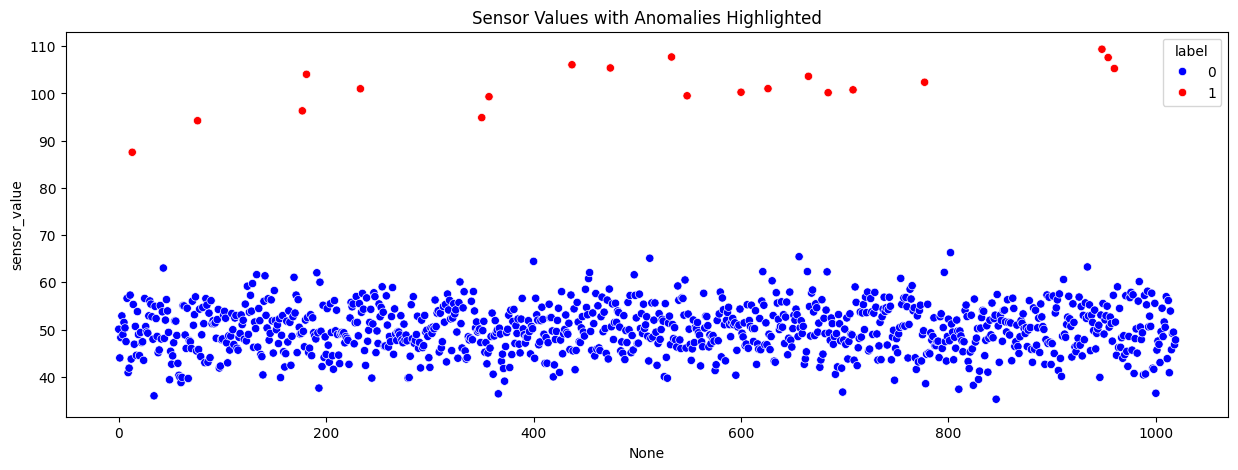

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/Synthetic_IoT_Anomaly_Dataset.csv')

# 1️⃣ First few rows
print("First 10 rows:\n", df.head(10))

# 2️⃣ Check info and missing values
print("\nDataset Info:\n")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# 3️⃣ Plot sensor readings over time
plt.figure(figsize=(15,5))
plt.plot(df['sensor_value'], label='Sensor Value')
plt.title('Sensor Readings Over Time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

# 4️⃣ Highlight anomalies
plt.figure(figsize=(15,5))
sns.scatterplot(x=df.index, y='sensor_value', hue='label', data=df, palette={0:'blue',1:'red'})
plt.title('Sensor Values with Anomalies Highlighted')
plt.show()


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

# 1️⃣ Feature Scaling
scaler = MinMaxScaler()
df['sensor_value_scaled'] = scaler.fit_transform(df[['sensor_value']])

# 2️⃣ Train-Test Split
X = df['sensor_value_scaled'].values
y = df['label'].values

# For LSTM, we need 3D shape: (samples, timesteps, features)
# We'll use timesteps = 1 for simplicity (each value as a sequence)
X = X.reshape(-1, 1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (816, 1, 1)
X_test shape: (204, 1, 1)
y_train shape: (816,)
y_test shape: (204,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 1)           │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.0493 - val_loss: 0.0337
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0287 - val_loss: 0.0156
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0130 - val_loss: 0.0080
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0094 - val_loss: 0.0076
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0084 - val_loss: 0.0065
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0071 - val_loss: 0.0055
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0056 - val_loss: 0.0042
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 - val_loss: 0.0029
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - val_loss: 0.0018
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.3689e-04 - val_loss: 6.8522e-04
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.3934

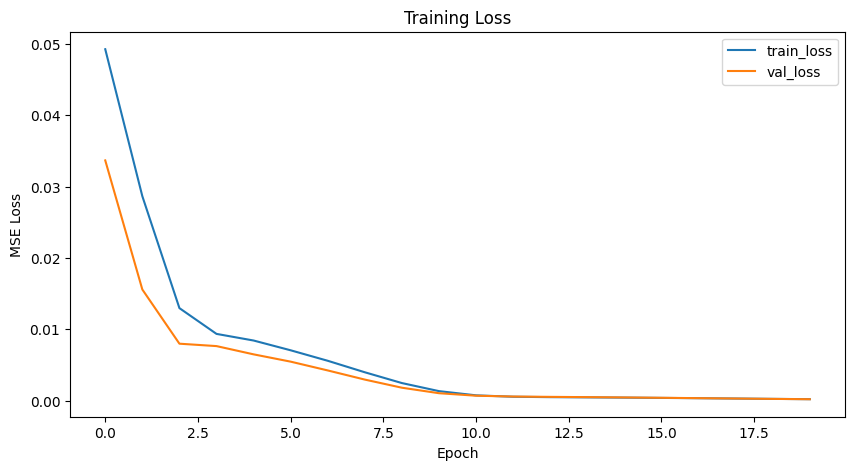

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
import matplotlib.pyplot as plt

# 1️⃣ Build LSTM Autoencoder
timesteps = X_train.shape[1]
features = X_train.shape[2]

model = Sequential([
    LSTM(64, activation='relu', input_shape=(timesteps, features), return_sequences=False),
    RepeatVector(timesteps),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(features))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# 2️⃣ Train the model
history = model.fit(X_train, X_train,
                    epochs=20,
                    batch_size=32,
                    validation_split=0.1,
                    shuffle=False)

# 3️⃣ Plot training loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()



In [ ]:
import numpy as np

# Predict on test data
X_test_pred = model.predict(X_test)

# Compute Mean Squared Error for each sample
mse = np.mean(np.power(X_test.reshape(X_test.shape[0], X_test.shape[2]) -
                       X_test_pred.reshape(X_test_pred.shape[0], X_test_pred.shape[2]), 2), axis=1)

# Set threshold (mean + 2*std of MSE on training set)
X_train_pred = model.predict(X_train)
mse_train = np.mean(np.power(X_train.reshape(X_train.shape[0], X_train.shape[2]) -
                             X_train_pred.reshape(X_train_pred.shape[0], X_train_pred.shape[2]), 2), axis=1)
threshold = np.mean(mse_train) + 2*np.std(mse_train)
print("Anomaly Detection Threshold:", threshold)

# Detect anomalies
y_pred = (mse > threshold).astype(int)

# Compare with true labels
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Anomaly Detection Threshold: 0.0009097899567853758
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       201
           1       0.43      1.00      0.60         3

    accuracy                           0.98       204
   macro avg       0.71      0.99      0.79       204
weighted avg       0.99      0.98      0.98       204



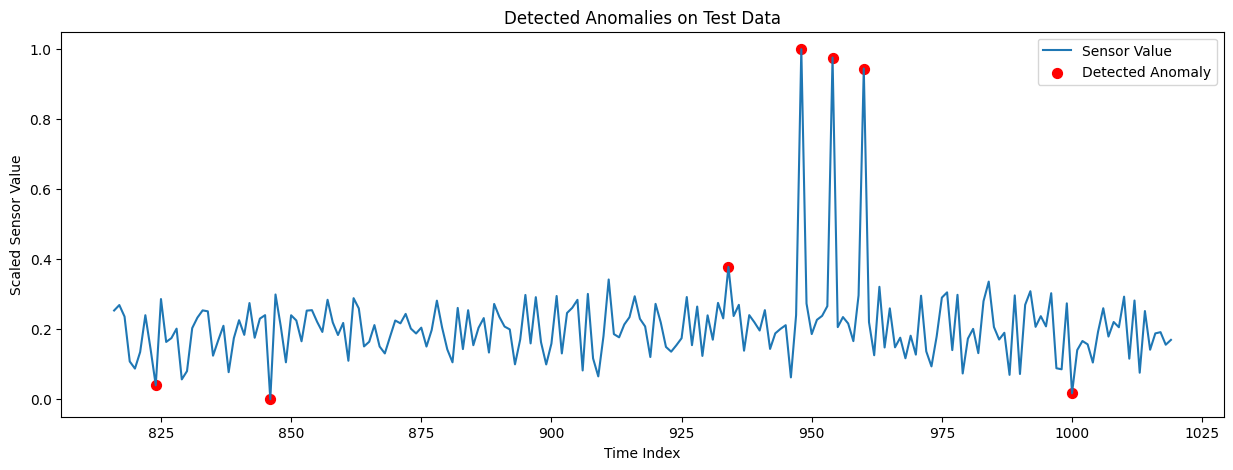

In [ ]:
import matplotlib.pyplot as plt

# Plot sensor values
plt.figure(figsize=(15,5))
plt.plot(df.index[-len(X_test):], X_test.reshape(X_test.shape[0], X_test.shape[2]), label='Sensor Value')

# Highlight detected anomalies
anomaly_indices = np.where(y_pred == 1)[0]
plt.scatter(df.index[-len(X_test):][anomaly_indices],
            X_test.reshape(X_test.shape[0], X_test.shape[2])[anomaly_indices],
            color='red', label='Detected Anomaly', s=50)

plt.title('Detected Anomalies on Test Data')
plt.xlabel('Time Index')
plt.ylabel('Scaled Sensor Value')
plt.legend()
plt.show()


In [ ]:
# Save the trained model
model.save("LSTM_Autoencoder_IoT.h5")
print("Model saved successfully!")


Model saved successfully!


In [ ]:
from google.colab import files
files.download("LSTM_Autoencoder_IoT.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd

# Generate 1000 normal readings
normal_data = np.random.normal(loc=50, scale=5, size=(1000, 1))

# Inject 20 anomalies
anomalies = np.random.normal(loc=100, scale=5, size=(20, 1))

# Combine normal and anomalous data
data = np.vstack([normal_data, anomalies])

# Create DataFrame
df = pd.DataFrame(data, columns=['sensor_value'])
df['label'] = [0]*1000 + [1]*20  # 0=normal, 1=anomaly

# Shuffle the dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save to CSV
df.to_csv("Synthetic_IoT_Anomaly_Dataset.csv", index=False)

# Show first few rows
df.head(10)


,sensor_value,label
0,48.221579,0
1,48.394903,0
2,48.932040,0
3,43.279239,0
4,58.691860,0
5,47.627420,0
6,47.826502,0
7,51.257592,0
8,50.585549,0
9,48.326508,0
